In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("telco_data.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            6293 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           6043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            4543 non-null   float64
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   6043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       5543 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
df.isnull().sum()

customerID             0
gender               750
SeniorCitizen          0
Partner             1000
Dependents             0
tenure              2500
PhoneService           0
MultipleLines          0
InternetService     1000
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV         1500
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges      1500
TotalCharges           0
Churn                  0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,4543.000000,5543.000000
mean,0.162147,32.546555,64.876403
std,0.368612,24.505519,30.101331
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.750000
50%,0.000000,29.000000,70.550000
75%,0.000000,56.000000,89.925000
max,1.000000,72.000000,118.600000


In [17]:
df.drop_duplicates(inplace=True)

In [22]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [26]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())

In [29]:
df['gender'].unique()

array(['Female', 'Male', nan], dtype=object)

In [30]:
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [27]:
from sklearn.preprocessing import LabelEncoder

In [34]:
le=LabelEncoder()
df['gender']=le.fit_transform(df['gender'])
df['Churn']=le.fit_transform(df['Churn'])

In [38]:
df.corr(numeric_only=True)

,gender,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
gender,1.000000,-0.001994,0.004031,-0.016145,-0.005338,-0.001350
SeniorCitizen,-0.001994,1.000000,0.005782,0.217877,0.102395,0.150889
tenure,0.004031,0.005782,1.000000,0.252183,0.824631,-0.336716
MonthlyCharges,-0.016145,0.217877,0.252183,1.000000,0.652728,0.189868
TotalCharges,-0.005338,0.102395,0.824631,0.652728,1.000000,-0.199428
Churn,-0.001350,0.150889,-0.336716,0.189868,-0.199428,1.000000


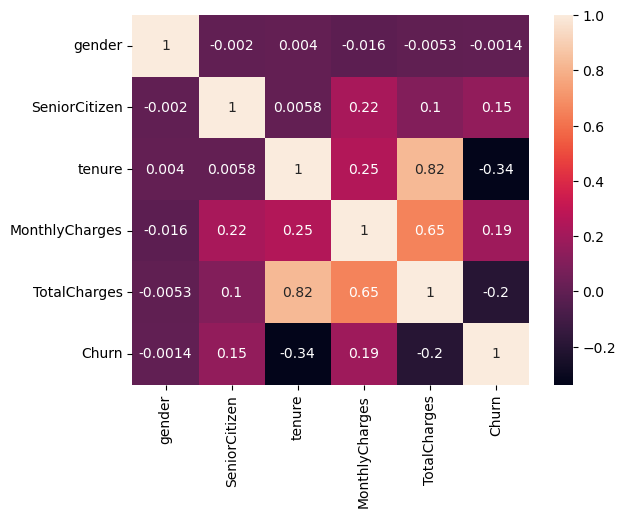

In [39]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

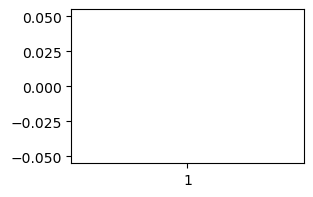

In [47]:
plt.figure(figsize=(3,2))
plt.boxplot(df['MonthlyCharges'])
plt.show()

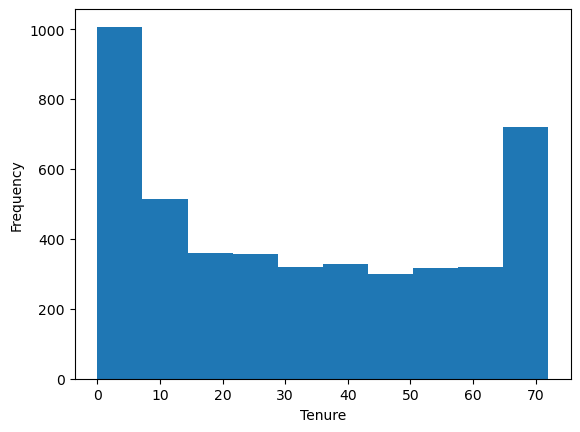

In [49]:
plt.hist(df['tenure'])
plt.xlabel("Tenure")
plt.ylabel("Frequency")
plt.show()

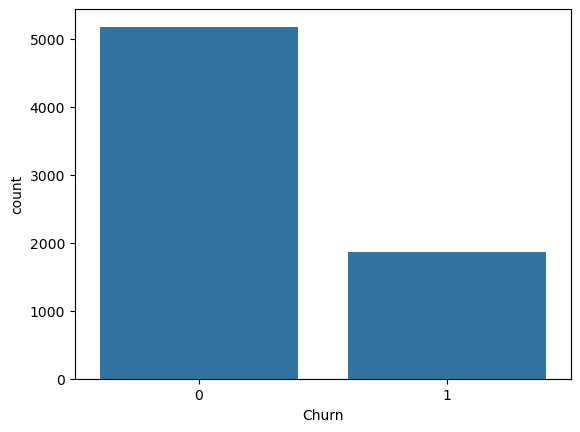

In [55]:
sns.countplot(x='Churn',data=df)
plt.show()

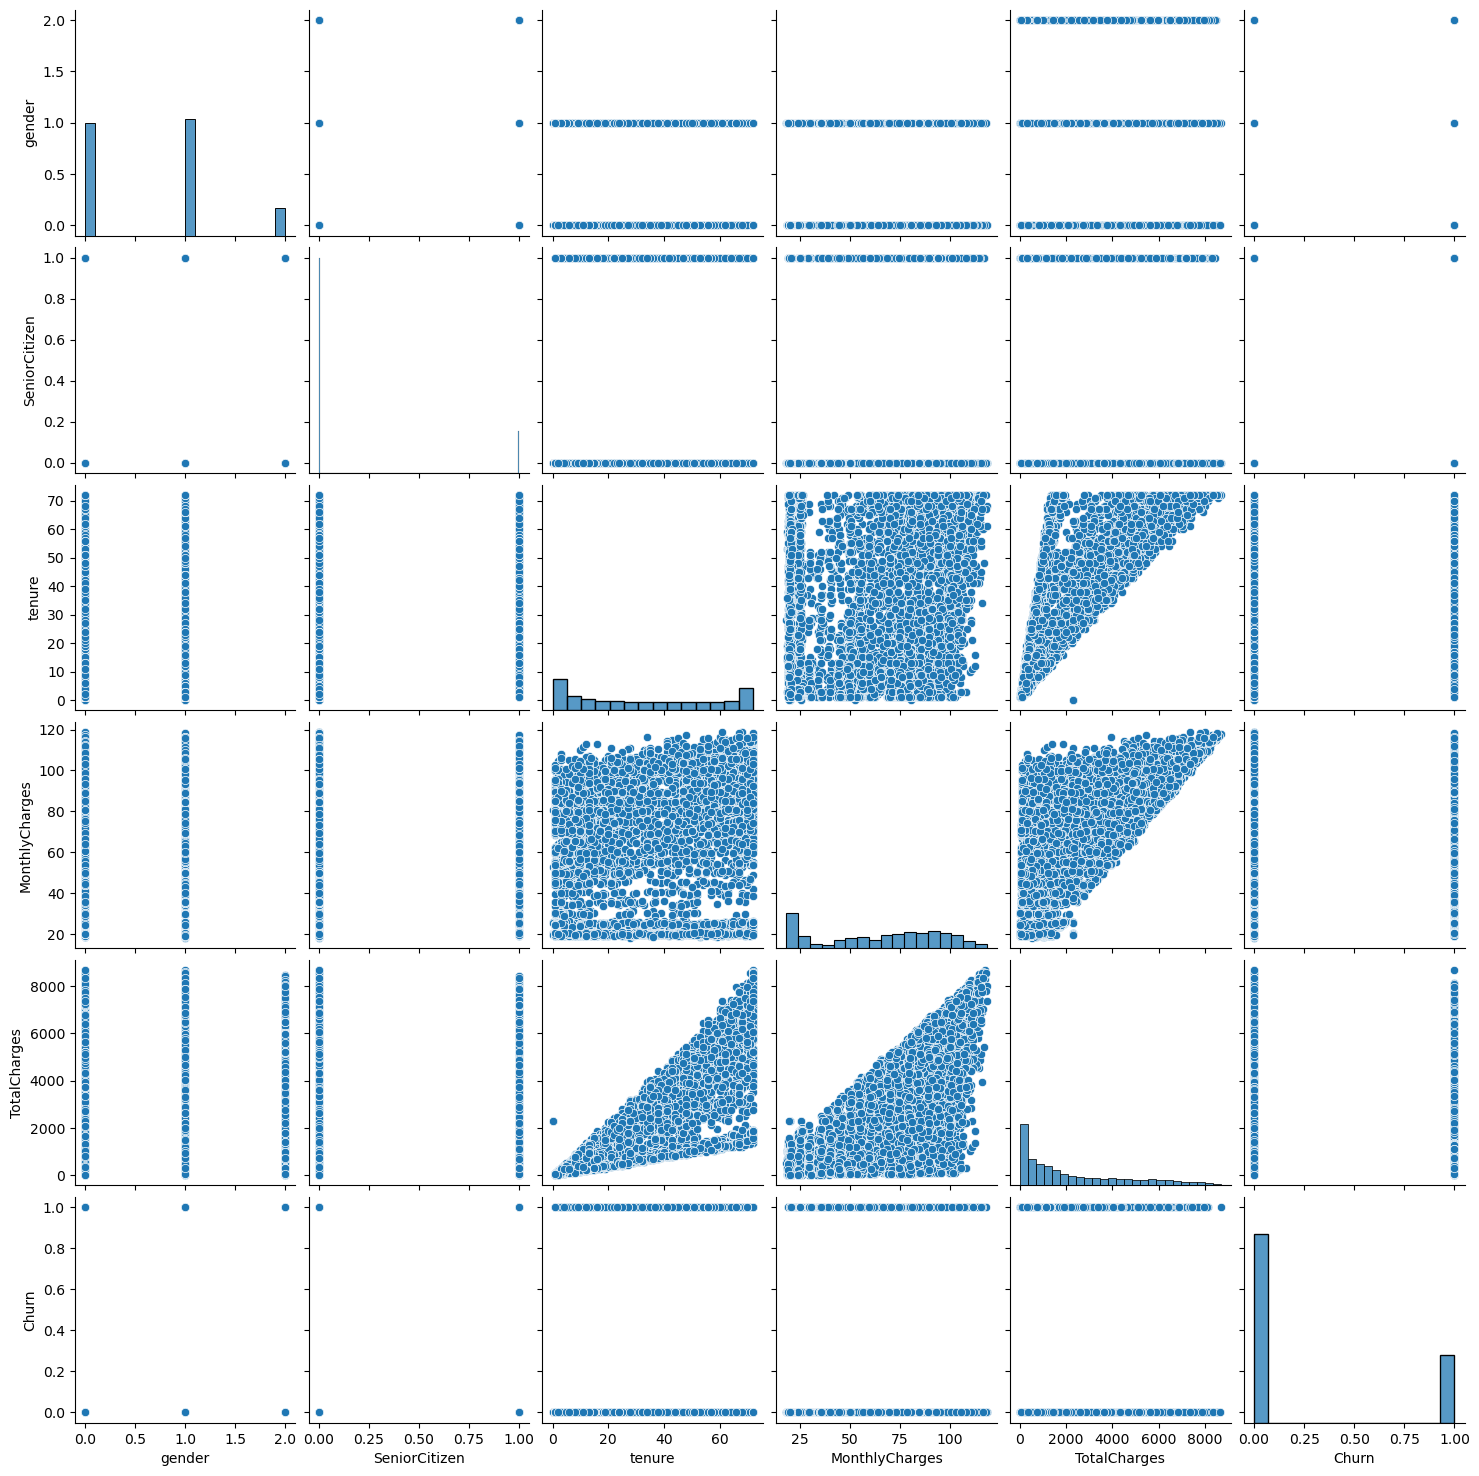

In [51]:
sns.pairplot(df)
plt.show()

In [56]:
from sklearn.preprocessing import StandardScaler

In [60]:
scaler=StandardScaler()
df[['MonthlyCharges']]=scaler.fit_transform(df[['MonthlyCharges']])

In [61]:
print(df['MonthlyCharges'].head())

0   -1.163721
1   -0.263348
2   -0.366343
3   -0.750081
4    0.193484
Name: MonthlyCharges, dtype: float64
